In [30]:
%load_ext autoreload
%autoreload 2

import pathlib
import os
import cv2 
from circles import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
files_path = pathlib.Path('freezing/')
files_list = sorted(pathlib.Path(files_path).glob('*.jpg'), key=lambda path: int(path.stem))

In [32]:
img = cv2.imread(str(files_list[0]))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_blur = cv2.medianBlur(gray, 5)

cv2.imshow('Median Blur',img_blur)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [33]:
Y1 = 100
Y2 = 400
X1 = 170
X2 = 480

img = cv2.imread(str(files_list[0]))
img = img[Y1:Y2, X1:X2]
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_blur = cv2.medianBlur(gray, 5)

cv2.imshow('Cropped image',img_blur)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [34]:
img = cv2.imread(str(files_list[0]))
img = img[Y1:Y2, X1:X2]

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = cv2.medianBlur(gray, 5)

dcirc = get_circles(img, param1=200, param2=7)

In [38]:
dcirc

[array([24, 24, 12]),
 array([88, 26, 11]),
 array([158,  24,  11]),
 array([222,  26,  12]),
 array([292,  22,  11]),
 array([30, 92, 11]),
 array([92, 96, 11]),
 array([160,  88,  12]),
 array([220,  88,  12]),
 array([284,  90,  12]),
 array([ 26, 160,  10]),
 array([ 90, 162,  12]),
 array([160, 158,  12]),
 array([222, 156,  11]),
 array([286, 162,  12]),
 array([ 24, 214,  12]),
 array([ 86, 226,  12]),
 array([154, 222,  12]),
 array([218, 218,  12]),
 array([292, 220,  12]),
 array([ 26, 278,  11]),
 array([ 92, 278,  12]),
 array([158, 276,  11]),
 array([226, 284,  12]),
 array([286, 274,  11])]

In [37]:
img = cv2.imread(str(files_list[500]))
img = img[Y1:Y2, X1:X2]

plot_detected_circles(img, dcirc)

In [39]:
res = []

for fi in files_list:
    img = cv2.imread(str(fi))
    img = img[Y1:Y2, X1:X2]

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_blur = cv2.medianBlur(gray, 5)
    
    res.append(get_grayscales(img_blur, dcirc))
    
res = np.array(res)

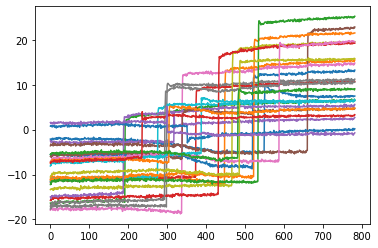

In [50]:
plt.plot(res)

In [51]:
res = []

for fi in files_list:
    img = cv2.imread(str(fi))
    img = img[Y1:Y2, X1:X2]

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_blur = cv2.medianBlur(gray, 5)
    
    res.append(get_grayscales(img_blur, dcirc, mask=False))
    
res = np.array(res)

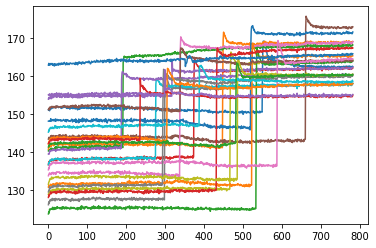

In [52]:
plt.plot(res)

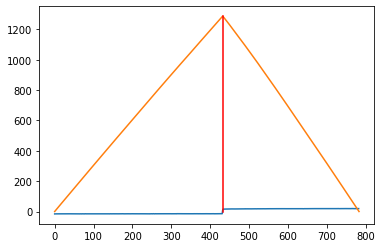

In [43]:
import matplotlib.pyplot as plt


dary = res[:,13]

# https://stackoverflow.com/questions/48000663/step-detection-in-one-dimensional-data
dary -= np.average(dary)
step = np.hstack((np.ones(len(dary)), -1*np.ones(len(dary))))
dary_step = np.convolve(dary, step, mode='valid')
step_indx = np.argmax(np.abs(dary_step))  

# plots
plt.plot(dary)
plt.plot(dary_step/10)
plt.plot((step_indx, step_indx), (dary_step[step_indx]/10, 0), 'r')

In [44]:
step_indx

432

In [45]:
freezing_idx = []

for i in range(25):
    dary = res[:,i]

    # https://stackoverflow.com/questions/48000663/step-detection-in-one-dimensional-data
    dary -= np.average(dary)
    step = np.hstack((np.ones(len(dary)), -1*np.ones(len(dary))))
    dary_step = np.convolve(dary, step, mode='valid')
    step_indx = np.argmax(dary_step)  
    freezing_idx.append(np.argmax(np.abs(dary_step)))

freezing_idx = np.array(freezing_idx)

In [25]:
freezing_idx

array([550, 448, 192, 374, 318, 661, 338, 299, 467, 276, 520, 523, 534,
       432, 188, 339, 588, 294, 486, 388, 352, 305, 482, 236, 301])

In [46]:
data = np.genfromtxt(files_path / 'log_data.csv', delimiter=',', names=True)

In [47]:
data.dtype.names

('Time_secs',
 'Frame_Number',
 'Setpoint_°C',
 'TC_Temperature_°C',
 'PRT_Temperature_°C',
 'Coolant_Flowrate_Lmin',
 'Throttle_',
 'Video_Fault_Flag')

In [48]:
t = []
ff = []

with open('lal.txt','w') as fo:
    for i, line in enumerate(data):
        t.append(line['TC_Temperature_°C'])
        ff.append((np.array(freezing_idx) <= i).sum()/25)
        fo.write(f'{i},{t[-1]},{ff[-1]}\n')

In [49]:
ff

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0

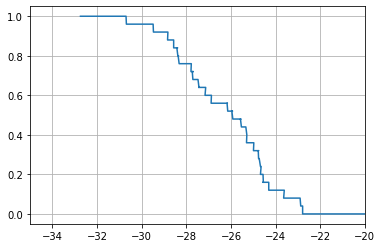

In [19]:
plt.plot(t,ff)
plt.xlim((-20,-35))
plt.gca().invert_xaxis()
plt.grid()